# Analyzing a real world data-set with SQL and Python


## Objectives

After completing this exercise, we will be able to:

*   Understand a dataset of selected socioeconomic indicators in Chicago
*   Learn how to store data in an SQLite database.
*   Solve example problems to practice your SQL skills


## Selected Socioeconomic Indicators in Chicago

The city of Chicago released a dataset of socioeconomic data to the Chicago City Portal.
This dataset contains a selection of six socioeconomic indicators of public health significance and a “hardship index,” for each Chicago community area, for the years 2008 – 2012.

Scores on the hardship index can range from 1 to 100, with a higher index number representing a greater level of hardship.

A detailed description of the dataset can be found on [the city of Chicago's website](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01), but to summarize, the dataset has the following variables:

*   **Community Area Number** (`ca`): Used to uniquely identify each row of the dataset

*   **Community Area Name** (`community_area_name`): The name of the region in the city of Chicago

*   **Percent of Housing Crowded** (`percent_of_housing_crowded`): Percent of occupied housing units with more than one person per room

*   **Percent Households Below Poverty** (`percent_households_below_poverty`): Percent of households living below the federal poverty line

*   **Percent Aged 16+ Unemployed** (`percent_aged_16_unemployed`): Percent of persons over the age of 16 years that are unemployed

*   **Percent Aged 25+ without High School Diploma** (`percent_aged_25_without_high_school_diploma`): Percent of persons over the age of 25 years without a high school education

*   **Percent Aged Under** 18 or Over 64:Percent of population under 18 or over 64 years of age (`percent_aged_under_18_or_over_64`): (ie. dependents)

*   **Per Capita Income** (`per_capita_income_`): Community Area per capita income is estimated as the sum of tract-level aggragate incomes divided by the total population

*   **Hardship Index** (`hardship_index`): Score that incorporates each of the six selected socioeconomic indicators

In this `**Practice Exercise**`, we'll take a look at the variables in the socioeconomic indicators dataset and do some basic analysis with Python.


### Connect to the database

Let us first load the SQL extension and establish a connection with the database

##### The syntax for connecting to magic sql using sqllite is

  **%sql sqlite://DatabaseName**   
  
where DatabaseName will be your **.db** file 


In [44]:
# Install any of the librarires, if not already installed

# !pip install ipython-sql
# !pip install seaborn
# !pip install pandas


In [45]:
# Loading the magic sql via load_ext function

%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [46]:
import csv, sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Creating and connecting to database
conn = sqlite3.connect("assets/3_Chicago_Socioeconomic_Data.db")
curr = conn.cursor()

In [47]:
# Connecting database to sql magic

%sql sqlite:///assets/3_Chicago_Socioeconomic_Data.db

'Connected: @assets/3_Chicago_Socioeconomic_Data.db'

### Store the dataset in a Table

##### In many cases the dataset to be analyzed is available as a .CSV (comma separated values) file, perhaps on the internet. To analyze the data using SQL, it first needs to be stored in the database.

##### We will first read the csv files  from the given url  into pandas dataframes

##### Next we will be using the  df.to_sql() function to convert each csv file  to a table in sqlite  with the csv data loaded in it.



In [48]:
import pandas
df = pandas.read_csv('https://data.cityofchicago.org/resource/jcxq-k9xf.csv')
df.to_sql("chicago_socioeconomic_data", conn, if_exists='replace', index=False,method="multi")

78

#### Explanation

##### Explanation of Parameters

| **Parameter** | **Description** |
|----------------|-----------------|
| `"chicago_socioeconomic_data"` | Name of the SQL table where the data will be stored. |
| `con` | Your database connection object. |
| `if_exists='replace'` | If the table already exists, delete it and recreate it.<br>Other options:<br>• `'fail'` → Raises an error if the table exists.<br>• `'append'` → Adds new rows to the existing table. |
| `index=False` | Prevents pandas from writing the DataFrame’s index as a separate column in the SQL table. |
| `method='multi'` | Inserts multiple rows per SQL statement, making it much faster for large datasets. |


In [49]:
# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable

# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'

##### You can verify that the table creation was successful by making a basic query like:


In [50]:
%sql SELECT * FROM chicago_socioeconomic_data limit 5;

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


## Problems

### Problem 1

##### How many rows are in the dataset?


In [51]:
%sql select count(*) from chicago_socioeconomic_data;

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


count(*)
78


### Problem 2

##### How many community areas in Chicago have a hardship index greater than 50.0?


In [52]:
%sql select count(*) from chicago_socioeconomic_data where hardship_index > 50.0; 

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


count(*)
38


### Problem 3

##### What is the maximum value of hardship index in this dataset?


In [53]:
%sql select max(hardship_index) from chicago_socioeconomic_data;


 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


max(hardship_index)
98.0


### Problem 4

##### Which community area which has the highest hardship index?


In [54]:
# Solution 1 to find just community area

%sql select ca from chicago_socioeconomic_data where hardship_index = ( select max(hardship_index) from chicago_socioeconomic_data);

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


ca
54.0


In [55]:
# Solution 1: to find just community area name 

%sql select community_area_name from chicago_socioeconomic_data where hardship_index = ( select max(hardship_index) from chicago_socioeconomic_data);

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


community_area_name
Riverdale


In [56]:
# Solution 2: as we know that hardship index is : 98.0, So;

%sql select community_area_name from chicago_socioeconomic_data where hardship_index = 98.0;

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


community_area_name
Riverdale


In [57]:
# Solution 3: by ordering the hardship_index in descending order and put limit = 1.

%sql select community_area_name from chicago_socioeconomic_data order by hardship_index desc limit 1;

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


community_area_name
Riverdale


### Problem 5

##### Which Chicago community areas have per-capita incomes greater than $60,000?


In [58]:
%sql select community_area_name from chicago_socioeconomic_data where per_capita_income_ > 60000;

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


community_area_name
Lake View
Lincoln Park
Near North Side
Loop


### Problem 6

##### Create a scatter plot using the variables `per_capita_income_` and `hardship_index`. Explain the correlation between the two variables.


In [59]:
# Creating dataframe of the whole sql data or chicago_socioeconomic_data.

chicago_economic_data = %sql select * from chicago_socioeconomic_data;
dataframe = chicago_economic_data.DataFrame()

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


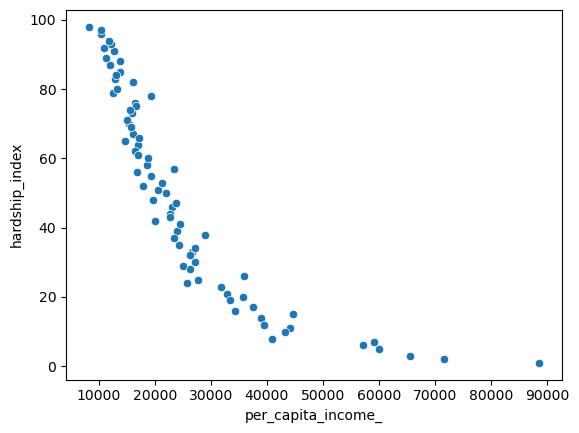

In [60]:
# Creating the scatterplot of two required variables.
import matplotlib.pyplot as plt
import seaborn as sns

plot = sns.scatterplot(x = "per_capita_income_", y = "hardship_index", data = dataframe)
plt.show()

#### Another solution for the problem 6

 * sqlite:///assets/3_Chicago_Socioeconomic_Data.db
   sqlite:///assets/3_Socioeconomic.db
Done.


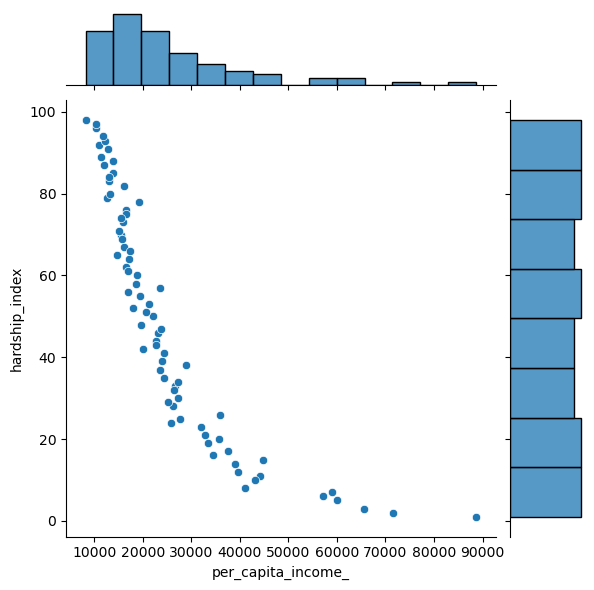

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

income_vs_hardship = %sql select per_capita_income_, hardship_index from chicago_socioeconomic_data;
plot = sns.jointplot(x = "per_capita_income_", y = "hardship_index", data = income_vs_hardship.DataFrame())
plt.show()

### Conclusion

##### Now that we know how to do basic exploratory data analysis using SQL and python visualization tools, we can further explore this dataset to see how the variable `per_capita_income_` is related to `percent_households_below_poverty` and `percent_aged_16_unemployed`. 


## Summary

##### In this Practice Exercise we learned how to store a real world data set from the internet in a database, gain insights into data using SQL queries. We also visualized a portion of the data in the database to see what story it tells.
